# 03. Player Points Prediction Dataset Construction

## 1. Research Goal

Цель этапа состоит в подготовке единого модельного датасета для прогнозирования количества очков игрока в конкретном матче NBA. Целевая переменная определяется как `target_points = PTS` в текущем матче.

Признаки формируются исключительно на основе информации, доступной до начала матча: историческая форма игрока, безопасный сезонный контекст, контекст команды и соперника, финансовые показатели и новостной фон.

## 2. Environment Setup

Раздел задает вычислительную среду и структуру хранения результатов, обеспечивая воспроизводимость построения итогового датасета.

In [ ]:
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 30)
sns.set_style("whitegrid")

In [ ]:
# Пути проекта
for p in [
    Path('data/processed'),
    Path('data/reports'),
    Path('artifacts/player_points/figures'),
    Path('artifacts/player_points/tables'),
    Path('docs'),
]:
    p.mkdir(parents=True, exist_ok=True)

## 3. Data Loading and Initial Validation

Раздел выполняет загрузку всех источников и первичную валидацию структуры, типов и временного покрытия.

In [ ]:
from pathlib import Path

BOX_SCORES_PATH = Path("NBA Player Box Score Stats(1950 - 2022).csv")
PLAYER_STATS_PATH = Path("NBA Player Stats(1950 - 2022).csv")
SALARIES_PATH = Path("NBA Salaries(1990-2023).csv")
PAYROLL_PATH = Path("NBA Payroll(1990-2023).csv")
NEWS_DAILY_PATH = Path("nba_news_daily_features.csv")

paths = {
    "box_scores_path": BOX_SCORES_PATH,
    "player_stats_path": PLAYER_STATS_PATH,
    "salaries_path": SALARIES_PATH,
    "payroll_path": PAYROLL_PATH,
    "news_daily_path": NEWS_DAILY_PATH,
}

for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {name} -> {path}")

box_scores_path = BOX_SCORES_PATH
player_stats_path = PLAYER_STATS_PATH
salaries_path = SALARIES_PATH
payroll_path = PAYROLL_PATH
news_daily_path = NEWS_DAILY_PATH

print("Все файлы успешно найдены:")
for name, path in paths.items():
    print(f"{name}: {path}")

Все файлы успешно найдены:
box_scores_path: NBA Player Box Score Stats(1950 - 2022).csv
player_stats_path: NBA Player Stats(1950 - 2022).csv
salaries_path: NBA Salaries(1990-2023).csv
payroll_path: NBA Payroll(1990-2023).csv
news_daily_path: nba_news_daily_features.csv


In [ ]:
# Загрузка данных
box_scores = pd.read_csv(box_scores_path)
player_stats = pd.read_csv(player_stats_path)
salaries = pd.read_csv(salaries_path)
payroll = pd.read_csv(payroll_path)
news_daily_features = pd.read_csv(news_daily_path)

datasets = {
    'box_scores': box_scores,
    'player_stats': player_stats,
    'salaries': salaries,
    'payroll': payroll,
    'news_daily_features': news_daily_features,
}

In [ ]:
# Нормализация колонок
for name, df in datasets.items():
    print('=' * 100)
    print(name, 'shape:', df.shape)
    print('columns:', list(df.columns))
    display(df.head(3))
    print(df.dtypes.head(20))

box_scores shape: (222215, 29)
columns: ['Unnamed: 0', 'Season', 'Game_ID', 'PLAYER_NAME', 'Team', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE']


,Unnamed: 0,Season,Game_ID,PLAYER_NAME,Team,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,531380,1946,24600034,Adolph Hoefer,HUS,"NOV 19, 1946",HUS vs. CLR,L,0,0,NaN,NaN,NaN,NaN,NaN,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,NaN,0.0
1,531378,1946,24600045,Adolph Hoefer,HUS,"NOV 23, 1946",HUS @ WAS,L,0,3,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,0.0
2,531379,1946,24600042,Adolph Hoefer,HUS,"NOV 22, 1946",HUS vs. BOS,W,0,1,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,NaN,0.0


Unnamed: 0       int64
Season           int64
Game_ID          int64
PLAYER_NAME     object
Team            object
GAME_DATE       object
MATCHUP         object
WL              object
MIN              int64
FGM              int64
FGA            float64
FG_PCT         float64
FG3M           float64
FG3A           float64
FG3_PCT        float64
FTM              int64
FTA            float64
FT_PCT         float64
OREB           float64
DREB           float64
dtype: object
player_stats shape: (28237, 32)
columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Season', 'Player', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']


,Unnamed: 0.1,Unnamed: 0,Season,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,0,0,1950,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,NaN,144.0,516.0,0.279,NaN,NaN,NaN,144.0,516.0,0.279,0.279,170.0,241.0,0.705,NaN,NaN,NaN,176.0,NaN,NaN,NaN,217.0,458.0
1,1,1,1950,Cliff Barker,SG,29.0,INO,49.0,NaN,NaN,102.0,274.0,0.372,NaN,NaN,NaN,102.0,274.0,0.372,0.372,75.0,106.0,0.708,NaN,NaN,NaN,109.0,NaN,NaN,NaN,99.0,279.0
2,2,2,1950,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,NaN,174.0,499.0,0.349,NaN,NaN,NaN,174.0,499.0,0.349,0.349,90.0,129.0,0.698,NaN,NaN,NaN,140.0,NaN,NaN,NaN,192.0,438.0


Unnamed: 0.1      int64
Unnamed: 0        int64
Season            int64
Player           object
Pos              object
Age             float64
Tm               object
G               float64
GS              float64
MP              float64
FG              float64
FGA             float64
FG%             float64
3P              float64
3PA             float64
3P%             float64
2P              float64
2PA             float64
2P%             float64
eFG%            float64
dtype: object
salaries shape: (15857, 5)
columns: ['Unnamed: 0', 'playerName', 'seasonStartYear', 'salary', 'inflationAdjSalary']


...

Unnamed: 0             int64
playerName            object
seasonStartYear        int64
salary                object
inflationAdjSalary    object
dtype: object
payroll shape: (966, 5)
columns: ['Unnamed: 0', 'team', 'seasonStartYear', 'payroll', 'inflationAdjPayroll']


,Unnamed: 0,team,seasonStartYear,payroll,inflationAdjPayroll
0,0,Cleveland,1990,"$14,403,000","$32,854,246"
1,1,New York,1990,"$13,290,000","$30,315,416"
2,2,Detroit,1990,"$12,910,000","$29,448,608"


Unnamed: 0              int64
team                   object
seasonStartYear         int64
payroll                object
inflationAdjPayroll    object
dtype: object
news_daily_features shape: (7038, 110)
columns: ['news_date', 'team', 'news_count', 'avg_gdelt_tone', 'min_gdelt_tone', 'max_gdelt_tone', 'avg_sentiment_score_kw', 'sum_positive_hits', 'sum_negative_hits', 'positive_news_count', 'negative_news_count', 'neutral_news_count', 'injury_news_count', 'trade_news_count', 'win_news_count', 'loss_news_count', 'playoff_news_count', 'roster_news_count', 'avg_title_len', 'avg_title_word_count', 'news_count_lag1', 'news_count_rollmean_3', 'news_count_rollmean_7', 'news_count_rollsum_3', 'news_count_rollsum_7', 'avg_gdelt_tone_lag1', 'avg_gdelt_tone_rollmean_3', 'avg_gdelt_tone_rollmean_7', 'avg_gdelt_tone_rollsum_3', 'avg_gdelt_tone_rollsum_7', 'min_gdelt_tone_lag1', 'min_gdelt_tone_rollmean_3', 'min_gdelt_tone_rollmean_7', 'min_gdelt_tone_rollsum_3', 'min_gdelt_tone_rollsum_7', 'max_gdel

,news_date,team,news_count,avg_gdelt_tone,min_gdelt_tone,max_gdelt_tone,avg_sentiment_score_kw,sum_positive_hits,sum_negative_hits,positive_news_count,negative_news_count,neutral_news_count,injury_news_count,trade_news_count,win_news_count,loss_news_count,playoff_news_count,roster_news_count,avg_title_len,avg_title_word_count,news_count_lag1,news_count_rollmean_3,news_count_rollmean_7,news_count_rollsum_3,news_count_rollsum_7,avg_gdelt_tone_lag1,avg_gdelt_tone_rollmean_3,avg_gdelt_tone_rollmean_7,avg_gdelt_tone_rollsum_3,avg_gdelt_tone_rollsum_7,min_gdelt_tone_lag1,min_gdelt_tone_rollmean_3,min_gdelt_tone_rollmean_7,min_gdelt_tone_rollsum_3,min_gdelt_tone_rollsum_7,max_gdelt_tone_lag1,max_gdelt_tone_rollmean_3,max_gdelt_tone_rollmean_7,max_gdelt_tone_rollsum_3,max_gdelt_tone_rollsum_7,avg_sentiment_score_kw_lag1,avg_sentiment_score_kw_rollmean_3,avg_sentiment_score_kw_rollmean_7,avg_sentiment_score_kw_rollsum_3,avg_sentiment_score_kw_rollsum_7,sum_positive_hits_lag1,sum_positive_hits_rollmean_3,sum_positive_hits_rollmean_7,sum_positive_hits_rollsum_3,sum_positive_hits_rollsum_7,sum_negative_hits_lag1,sum_negative_hits_rollmean_3,sum_negative_hits_rollmean_7,sum_negative_hits_rollsum_3,sum_negative_hits_rollsum_7,positive_news_count_lag1,positive_news_count_rollmean_3,positive_news_count_rollmean_7,positive_news_count_rollsum_3,positive_news_count_rollsum_7,negative_news_count_lag1,negative_news_count_rollmean_3,negative_news_count_rollmean_7,negative_news_count_rollsum_3,negative_news_count_rollsum_7,neutral_news_count_lag1,neutral_news_count_rollmean_3,neutral_news_count_rollmean_7,neutral_news_count_rollsum_3,neutral_news_count_rollsum_7,injury_news_count_lag1,injury_news_count_rollmean_3,injury_news_count_rollmean_7,injury_news_count_rollsum_3,injury_news_count_rollsum_7,trade_news_count_lag1,trade_news_count_rollmean_3,trade_news_count_rollmean_7,trade_news_count_rollsum_3,trade_news_count_rollsum_7,win_news_count_lag1,win_news_count_rollmean_3,win_news_count_rollmean_7,win_news_count_rollsum_3,win_news_count_rollsum_7,loss_news_count_lag1,loss_news_count_rollmean_3,loss_news_count_rollmean_7,loss_news_count_rollsum_3,loss_news_count_rollsum_7,playoff_news_count_lag1,playoff_news_count_rollmean_3,playoff_news_count_rollmean_7,playoff_news_count_rollsum_3,playoff_news_count_rollsum_7,roster_news_count_lag1,roster_news_count_rollmean_3,roster_news_count_rollmean_7,roster_news_count_rollsum_3,roster_news_count_rollsum_7,avg_title_len_lag1,avg_title_len_rollmean_3,avg_title_len_rollmean_7,avg_title_len_rollsum_3,avg_title_len_rollsum_7,avg_title_word_count_lag1,avg_title_word_count_rollmean_3,avg_title_word_count_rollmean_7,avg_title_word_count_rollsum_3,avg_title_word_count_rollsum_7
0,2020-01-04,ATL,3,-0.063511,-1.279318,1.880342,0.0,0,0,0,0,3,0,3,0,0,0,0,71.666667,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-05,ATL,1,-2.260870,-2.260870,-2.260870,0.0,0,0,0,0,1,0,0,0,0,0,0,47.000000,8.0,3.0,3.0,3.0,3.0,3.0,-0.063511,-0.063511,-0.063511,-0.063511,-0.063511,-1.279318,-1.279318,-1.279318,-1.279318,-1.279318,1.880342,1.880342,1.880342,1.880342,1.880342,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,71.666667,71.666667,71.666667,71.666667,71.666667,12.0,12.0,12.0,12.0,12.0
2,2020-01-06,ATL,1,-1.426025,-1.426025,-1.426025,1.0,1,0,1,0,0,0,0,1,0,0,0,53.000000,9.0,1.0,2.0,2.0,4.0,4.0,-2.260870,-1.162190,-1.162190,-2.324380,-2.324380,-2.260870,-1.770094,-1.770094,-3.540187,-3.540187,-2.260870,-0.190264,-0.190264,-0.380528

news_date                  object
team                       object
news_count                  int64
avg_gdelt_tone            float64
min_gdelt_tone            float64
max_gdelt_tone            float64
avg_sentiment_score_kw    float64
sum_positive_hits           int64
sum_negative_hits           int64
positive_news_count         int64
negative_news_count         int64
neutral_news_count          int64
injury_news_count           int64
trade_news_count            int64
win_news_count              int64
loss_news_count             int64
playoff_news_count          int64
roster_news_count           int64
avg_title_len             float64
avg_title_word_count      float64
dtype: object


## 4. Dataset Granularity and Target Definition

Источники имеют разную гранулярность: `box_scores` — игрок × матч, `player_stats` и `salaries` — игрок × сезон, `payroll` — команда × сезон, `news_daily_features` — команда × дата. Итоговая гранулярность датасета фиксируется как «игрок × матч».

Целевая переменная определяется как `target_points = PTS` в текущем матче. Значение целевой переменной не включается в набор предикторов.

## 5. Column Standardization

Раздел обеспечивает единые ключи объединения и устраняет технические артефакты исходных файлов.

In [ ]:
# Нормализация колонок
for k in datasets:
    datasets[k] = datasets[k].loc[:, ~datasets[k].columns.str.startswith('Unnamed')].copy()

box_scores = datasets['box_scores'].rename(columns={
    'Season': 'season', 'Game_ID': 'game_id', 'PLAYER_NAME': 'player', 'Team': 'team',
    'GAME_DATE': 'game_date', 'MATCHUP': 'matchup', 'WL': 'result', 'MIN': 'minutes'
})

player_stats = datasets['player_stats'].rename(columns={
    'Season': 'season', 'Player': 'player', 'Tm': 'team', 'Pos': 'position', 'Age': 'age'
})

salaries = datasets['salaries'].rename(columns={'playerName': 'player', 'seasonStartYear': 'season'})
payroll = datasets['payroll'].rename(columns={'seasonStartYear': 'season'})
news_daily_features = datasets['news_daily_features'].copy()


def normalize_text(s: pd.Series) -> pd.Series:
    return s.astype(str).str.upper().str.strip().str.replace(r'\s+', ' ', regex=True)

for df, col in [(box_scores, 'team'), (player_stats, 'team'), (news_daily_features, 'team')]:
    if col in df.columns:
        df[col] = normalize_text(df[col])

for df in [box_scores, player_stats, salaries, payroll]:
    if 'player' in df.columns:
        df['player'] = df['player'].astype(str).str.strip()
    if 'season' in df.columns:
        df['season'] = pd.to_numeric(df['season'], errors='coerce')

news_daily_features['news_date'] = pd.to_datetime(news_daily_features['news_date'], errors='coerce')

## 6. Date Parsing and Match Context

Раздел формирует матчевый контекст и целевую переменную. Корректный парсинг дат выполняется без жесткого формата.

bad game_date share: 0.0
date range: 1946-11-01 00:00:00 -> 1974-12-30 00:00:00
unique players: 1241
unique games: 11810


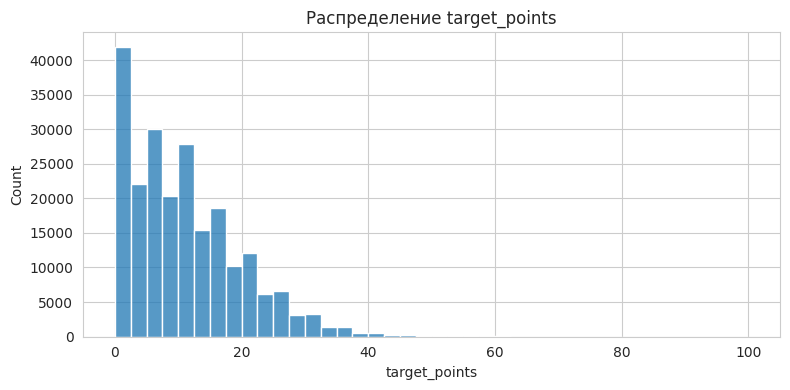

In [ ]:
# Нормализация колонок
box_scores['game_date'] = pd.to_datetime(box_scores['game_date'], errors='coerce')
box_scores['opponent'] = box_scores['matchup'].astype(str).str.extract(r'(?:vs\.|@)\s*([A-Z]{2,3})', expand=False)
box_scores['is_home'] = box_scores['matchup'].astype(str).str.contains('vs\.', regex=True, na=False).astype(int)
box_scores['win_flag'] = (box_scores['result'] == 'W').astype(int)
box_scores['target_points'] = pd.to_numeric(box_scores['PTS'], errors='coerce')

print('bad game_date share:', round(box_scores['game_date'].isna().mean(), 6))
print('date range:', box_scores['game_date'].min(), '->', box_scores['game_date'].max())
print('unique players:', box_scores['player'].nunique())
print('unique games:', box_scores['game_id'].nunique())

plt.figure(figsize=(8,4))
sns.histplot(box_scores['target_points'].dropna(), bins=40)
plt.title('Распределение target_points')
plt.tight_layout()
plt.show()

## 7. Base Player-Game Dataset

Раздел формирует базовую таблицу уровня «игрок × матч» с обязательными служебными полями и исходными матчевыми метриками, используемыми только для построения исторических признаков.

In [ ]:
# Агрегация командной статистики
base_cols = ['player','season','game_id','game_date','team','opponent','is_home','result','win_flag','minutes','target_points']
match_stat_cols = ['PTS','FGM','FGA','FG3M','FG3A','FTM','FTA','REB','AST','STL','BLK','TOV','PF','PLUS_MINUS']
existing_stat_cols = [c for c in match_stat_cols if c in box_scores.columns]

player_game = box_scores[base_cols + existing_stat_cols].copy()

for c in ['minutes'] + existing_stat_cols:
    if c in player_game.columns:
        player_game[c] = pd.to_numeric(player_game[c], errors='coerce')

print('player_game shape:', player_game.shape)
display(player_game.head(5))

player_game shape: (222215, 25)


,player,season,game_id,game_date,team,opponent,is_home,result,win_flag,minutes,target_points,PTS,FGM,FGA,FG3M,FG3A,FTM,FTA,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,Adolph Hoefer,1946,24600034,1946-11-19,HUS,CLR,1,L,0,0,0.0,0.0,0,NaN,NaN,NaN,0,0.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
1,Adolph Hoefer,1946,24600045,1946-11-23,HUS,WAS,0,L,0,0,7.0,7.0,3,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Adolph Hoefer,1946,24600042,1946-11-22,HUS,BOS,1,W,1,0,6.0,6.0,1,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Adolph Hoefer,1946,24600051,1946-11-26,HUS,WAS,1,L,0,0,10.0,10.0,5,NaN,NaN,NaN,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Adolph Hoefer,1946,24600061,1946-11-29,HUS,CLR,1,L,0,0,2.0,2.0,0,NaN,NaN,NaN,2,2.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN


## 8. Player Historical Form Features

Раздел строит rolling-признаки формы игрока только на основе предыдущих матчей через `shift(1)`. Такой подход исключает утечку информации текущей игры.

In [ ]:
# Формирование rolling-признаков
safe_div = lambda a, b: np.where(pd.to_numeric(b, errors='coerce') > 0, pd.to_numeric(a, errors='coerce') / pd.to_numeric(b, errors='coerce'), np.nan)

player_game['efficiency_score'] = (
    player_game[['PTS','REB','AST','STL','BLK']].sum(axis=1, min_count=1)
    - player_game[['TOV','PF']].sum(axis=1, min_count=1)
)
player_game['true_shooting_pct'] = safe_div(player_game.get('PTS'), 2 * (player_game.get('FGA') + 0.44 * player_game.get('FTA')))
player_game['usage_proxy'] = safe_div(player_game.get('FGA') + 0.44 * player_game.get('FTA') + player_game.get('TOV'), player_game.get('minutes'))
player_game['fg_pct'] = safe_div(player_game.get('FGM'), player_game.get('FGA'))

player_game = player_game.sort_values(['player','game_date'])

rolling_map = {
    'PTS': 'player_pts', 'minutes': 'player_minutes', 'FGA': 'player_fga', 'FGM': 'player_fgm',
    'FG3A': 'player_fg3a', 'FG3M': 'player_fg3m', 'FTA': 'player_fta', 'REB': 'player_reb',
    'AST': 'player_ast', 'TOV': 'player_tov', 'PLUS_MINUS': 'player_plus_minus',
    'efficiency_score': 'player_efficiency', 'true_shooting_pct': 'player_ts_pct', 'usage_proxy': 'player_usage_proxy',
    'fg_pct': 'player_fg_pct'
}

for w in [3, 5, 10]:
    for src, dst in rolling_map.items():
        if src in player_game.columns:
            player_game[f'{dst}_last{w}'] = (
                player_game.groupby('player')[src]
                .shift(1)
                .rolling(window=w, min_periods=1)
                .mean()
                .values
            )

player_game['player_points_std_last10'] = player_game.groupby('player')['PTS'].shift(1).rolling(10, min_periods=2).std().values
player_game['player_minutes_std_last10'] = player_game.groupby('player')['minutes'].shift(1).rolling(10, min_periods=2).std().values

print('rolling features created:', len([c for c in player_game.columns if 'last' in c or 'std_last10' in c]))

rolling features created: 47


Краткий вывод: исторические признаки игрока отражают предматчевую форму и допускают корректное использование в прогнозной задаче.

## 9. Player Season Context Features

Раздел формирует сезонный контекст игрока и безопасный вариант переноса признаков из предыдущего сезона. Для итогового датасета применяется `season_context_previous`.

In [ ]:
# Формирование признаков
ps = player_stats.copy()
for c in ['age','G','GS','MP','PTS','AST','TRB','STL','BLK','TOV','PF','FGA','FTA','FG','3P']:
    if c in ps.columns:
        ps[c] = pd.to_numeric(ps[c], errors='coerce')

ps['pts_per_game_season'] = safe_div(ps.get('PTS'), ps.get('G'))
ps['ast_per_game_season'] = safe_div(ps.get('AST'), ps.get('G'))
ps['trb_per_game_season'] = safe_div(ps.get('TRB'), ps.get('G'))
ps['mp_per_game_season'] = safe_div(ps.get('MP'), ps.get('G'))
ps['pts_per_36_season'] = 36 * safe_div(ps.get('PTS'), ps.get('MP'))
ps['ast_per_36_season'] = 36 * safe_div(ps.get('AST'), ps.get('MP'))
ps['trb_per_36_season'] = 36 * safe_div(ps.get('TRB'), ps.get('MP'))
ps['true_shooting_pct_season'] = safe_div(ps.get('PTS'), 2 * (ps.get('FGA') + 0.44 * ps.get('FTA')))
ps['ast_to_tov_season'] = safe_div(ps.get('AST'), ps.get('TOV'))
ps['usage_proxy_season'] = safe_div(ps.get('FGA') + 0.44 * ps.get('FTA') + ps.get('TOV'), ps.get('MP'))
ps['age_sq'] = ps['age'] ** 2

season_cols = [
    'position','age','G','GS','MP','PTS','AST','TRB','STL','BLK','TOV','PF','FG%','3P%','FT%','eFG%',
    'pts_per_game_season','ast_per_game_season','trb_per_game_season','mp_per_game_season',
    'pts_per_36_season','ast_per_36_season','trb_per_36_season','true_shooting_pct_season','ast_to_tov_season','usage_proxy_season','age_sq'
]
season_cols = [c for c in season_cols if c in ps.columns]

season_context_full = ps[['player','season','team'] + season_cols].copy()
season_context_previous = season_context_full.copy()
season_context_previous['season'] = season_context_previous['season'] + 1
season_context_previous = season_context_previous.rename(columns={c: f'previous_{c}' for c in season_cols + ['team']})

display(season_context_previous.head(5))

,player,season,previous_team,previous_position,previous_age,previous_G,previous_GS,previous_MP,previous_PTS,previous_AST,previous_TRB,previous_STL,previous_BLK,previous_TOV,previous_PF,previous_FG%,previous_3P%,previous_FT%,previous_eFG%,previous_pts_per_game_season,previous_ast_per_game_season,previous_trb_per_game_season,previous_mp_per_game_season,previous_pts_per_36_season,previous_ast_per_36_season,previous_trb_per_36_season,previous_true_shooting_pct_season,previous_ast_to_tov_season,previous_usage_proxy_season,previous_age_sq
0,Curly Armstrong,1951,FTW,G-F,31.0,63.0,NaN,NaN,458.0,176.0,NaN,NaN,NaN,NaN,217.0,0.279,NaN,0.705,0.279,7.269841,2.793651,NaN,NaN,NaN,NaN,NaN,0.368144,NaN,NaN,961.0
1,Cliff Barker,1951,INO,SG,29.0,49.0,NaN,NaN,279.0,109.0,NaN,NaN,NaN,NaN,99.0,0.372,NaN,0.708,0.372,5.693878,2.224490,NaN,NaN,NaN,NaN,NaN,0.435067,NaN,NaN,841.0
2,Leo Barnhorst,1951,CHS,SF,25.0,67.0,NaN,NaN,438.0,140.0,NaN,NaN,NaN,NaN,192.0,0.349,NaN,0.698,0.349,6.537313,2.089552,NaN,NaN,NaN,NaN,NaN,0.394055,NaN,NaN,625.0
3,Ed Bartels,1951,TOT,F,24.0,15.0,NaN,NaN,63.0,20.0,NaN,NaN,NaN,NaN,29.0,0.256,NaN,0.559,0.256,4.200000,1.333333,NaN,NaN,NaN,NaN,NaN,0.312005,NaN,NaN,576.0
4,Ed Bartels,1951,DNN,F,24.0,13.0,NaN,NaN,59.0,20.0,NaN,NaN,NaN,NaN,27.0,0.256,NaN,0.548,0.256,4.538462,1.538462,NaN,NaN,NaN,NaN,NaN,0.308448,NaN,NaN,576.0


## 10. Team Form Features

Раздел агрегирует данные на уровне «команда × матч» и строит rolling-признаки формы команды через `shift(1)`.

In [ ]:
# Агрегация командной статистики
team_game = (
    player_game.groupby(['game_id','game_date','season','team'], as_index=False)
    .agg({
        'PTS':'sum','AST':'sum','REB':'sum','TOV':'sum','FGM':'sum','FGA':'sum','FG3M':'sum','FG3A':'sum','FTM':'sum','FTA':'sum',
        'win_flag':'max','STL':'sum','BLK':'sum','minutes':'sum'
    })
)

team_game['team_fg_pct'] = safe_div(team_game['FGM'], team_game['FGA'])
team_game['team_fg3_pct'] = safe_div(team_game['FG3M'], team_game['FG3A'])
team_game['team_ft_pct'] = safe_div(team_game['FTM'], team_game['FTA'])
team_game['team_pace_proxy'] = team_game['FGA'] + 0.44 * team_game['FTA'] + team_game['TOV']
team_game['team_efficiency_proxy'] = team_game['PTS'] + team_game['REB'] + team_game['AST'] + team_game['STL'] + team_game['BLK'] - team_game['TOV']

team_game = team_game.sort_values(['team','game_date'])
for src, pref in [
    ('PTS','team_pts'),('AST','team_ast'),('REB','team_reb'),('TOV','team_tov'),('win_flag','team_win_rate'),
    ('team_fg_pct','team_fg_pct'),('team_fg3_pct','team_fg3_pct'),('team_ft_pct','team_ft_pct'),
    ('team_pace_proxy','team_pace_proxy'),('team_efficiency_proxy','team_efficiency_proxy')
]:
    team_game[f'{pref}_last5'] = team_game.groupby('team')[src].shift(1).rolling(5, min_periods=1).mean().values

team_feature_cols = [c for c in team_game.columns if c.endswith('_last5')]

Краткий вывод: командные rolling-признаки добавляют предматчевый контекст состояния коллектива и темпа игры.

## 11. Opponent Strength Features

Раздел добавляет силу соперника на основе его предматчевых командных признаков и формирует относительные diff-показатели.

In [ ]:
# Объединение признаков соперника
team_small = team_game[['game_id','team'] + team_feature_cols].copy()
opp = team_small.rename(columns={'team':'opponent', **{c:f'opponent_{c}' for c in team_feature_cols}})
team_with_opp = team_small.merge(opp, on=['game_id'], how='left')
team_with_opp = team_with_opp[team_with_opp['team'] != team_with_opp['opponent']]
team_with_opp = team_with_opp.drop_duplicates(subset=['game_id','team'])

team_with_opp['opponent_pts_allowed_proxy_last5'] = team_with_opp['opponent_team_pts_last5'] if 'opponent_team_pts_last5' in team_with_opp.columns else np.nan
team_with_opp['opponent_win_rate_last5'] = team_with_opp.get('opponent_team_win_rate_last5')
team_with_opp['opponent_reb_last5'] = team_with_opp.get('opponent_team_reb_last5')
team_with_opp['opponent_tov_last5'] = team_with_opp.get('opponent_team_tov_last5')
team_with_opp['opponent_defense_proxy_last5'] = (
    team_with_opp.get('opponent_team_reb_last5', 0) +
    team_with_opp.get('opponent_team_tov_last5', 0)
)

team_with_opp['team_win_rate_last5_diff'] = team_with_opp.get('team_win_rate_last5') - team_with_opp.get('opponent_team_win_rate_last5')
team_with_opp['team_pts_last5_diff'] = team_with_opp.get('team_pts_last5') - team_with_opp.get('opponent_team_pts_last5')
team_with_opp['team_efficiency_last5_diff'] = team_with_opp.get('team_efficiency_proxy_last5') - team_with_opp.get('opponent_team_efficiency_proxy_last5')

## 12. Salary and Payroll Player Features

Раздел формирует финансовые признаки игрока и команды, включая ранги внутри команды и долю от payroll.

In [ ]:
# Формирование признаков
sal = salaries.copy()
if 'salary' not in sal.columns and 'salaryValue' in sal.columns:
    sal = sal.rename(columns={'salaryValue':'salary'})
sal['salary_numeric'] = pd.to_numeric(sal.get('salary'), errors='coerce')
sal['inflation_adj_salary_numeric'] = pd.to_numeric(sal.get('inflationAdjSalary'), errors='coerce')
sal['player'] = sal['player'].astype(str).str.strip()
sal['season'] = pd.to_numeric(sal['season'], errors='coerce')

sal_team = sal.merge(ps[['player','season','team']].drop_duplicates(), on=['player','season'], how='left')
salary_coverage = float(sal_team['team'].notna().mean())

sal_team['salary_rank_in_team'] = sal_team.groupby(['team','season'])['salary_numeric'].rank(method='average', ascending=False)
sal_team['salary_percentile_in_team'] = sal_team.groupby(['team','season'])['salary_numeric'].rank(pct=True)
team_salary_total = sal_team.groupby(['team','season'])['salary_numeric'].sum().reset_index(name='team_salary_total')
sal_team = sal_team.merge(team_salary_total, on=['team','season'], how='left')
sal_team['salary_share_of_team_salary'] = safe_div(sal_team['salary_numeric'], sal_team['team_salary_total'])
sal_team['log_salary'] = np.log1p(sal_team['salary_numeric'])

TEAM_NAME_TO_ABBR = {
    'ATLANTA HAWKS':'ATL','BOSTON CELTICS':'BOS','BROOKLYN NETS':'BKN','NEW JERSEY NETS':'NJN','CHARLOTTE HORNETS':'CHA',
    'CHARLOTTE BOBCATS':'CHA','CHICAGO BULLS':'CHI','CLEVELAND CAVALIERS':'CLE','DALLAS MAVERICKS':'DAL','DENVER NUGGETS':'DEN',
    'DETROIT PISTONS':'DET','GOLDEN STATE WARRIORS':'GSW','HOUSTON ROCKETS':'HOU','INDIANA PACERS':'IND','LOS ANGELES CLIPPERS':'LAC',
    'LA CLIPPERS':'LAC','LOS ANGELES LAKERS':'LAL','MEMPHIS GRIZZLIES':'MEM','VANCOUVER GRIZZLIES':'VAN','MIAMI HEAT':'MIA',
    'MILWAUKEE BUCKS':'MIL','MINNESOTA TIMBERWOLVES':'MIN','NEW ORLEANS PELICANS':'NOP','NEW ORLEANS HORNETS':'NOH','NEW YORK KNICKS':'NYK',
    'OKLAHOMA CITY THUNDER':'OKC','SEATTLE SUPERSONICS':'SEA','ORLANDO MAGIC':'ORL','PHILADELPHIA 76ERS':'PHI','PHOENIX SUNS':'PHX',
    'PORTLAND TRAIL BLAZERS':'POR','SACRAMENTO KINGS':'SAC','SAN ANTONIO SPURS':'SAS','TORONTO RAPTORS':'TOR','UTAH JAZZ':'UTA',
    'WASHINGTON WIZARDS':'WAS','WASHINGTON BULLETS':'WSB'
}

pr = payroll.copy()
if 'teamName' in pr.columns:
    pr['team'] = normalize_text(pr['teamName']).map(TEAM_NAME_TO_ABBR).fillna(normalize_text(pr['teamName']))
elif 'team' in pr.columns:
    pr['team'] = normalize_text(pr['team'])

pr['season'] = pd.to_numeric(pr['season'], errors='coerce')
pr['payroll_numeric'] = pd.to_numeric(pr.get('payroll'), errors='coerce')
pr['inflation_adj_payroll_numeric'] = pd.to_numeric(pr.get('inflationAdjPayroll'), errors='coerce')
pr['team_payroll_rank'] = pr.groupby('season')['payroll_numeric'].rank(method='average', ascending=False)
pr['team_payroll_percentile'] = pr.groupby('season')['payroll_numeric'].rank(pct=True)

player_financial = sal_team[['player','season','team','salary_numeric','inflation_adj_salary_numeric','log_salary','salary_rank_in_team','salary_percentile_in_team','salary_share_of_team_salary']].copy()
player_financial = player_financial.merge(
    pr[['team','season','payroll_numeric','inflation_adj_payroll_numeric','team_payroll_rank','team_payroll_percentile']].drop_duplicates(),
    on=['team','season'], how='left'
)
player_financial['salary_share_of_payroll'] = safe_div(player_financial['salary_numeric'], player_financial['payroll_numeric'])

payroll_coverage = float(player_financial['payroll_numeric'].notna().mean())
print('salary coverage:', round(salary_coverage, 4))
print('payroll coverage:', round(payroll_coverage, 4))

Краткий вывод: финансовый блок интегрирован с явной оценкой покрытия, что фиксирует надежность признаков зарплат и payroll.

## 13. News Features

Раздел строит только lag/rolling признаки новостей для исключения использования информации, потенциально опубликованной после начала матча.

In [ ]:
# Подключение новостных признаков
news = news_daily_features.copy()
news['team'] = normalize_text(news['team'])
news['news_date'] = pd.to_datetime(news['news_date'], errors='coerce')
news = news.sort_values(['team','news_date'])

news_base = ['news_count','avg_gdelt_tone','injury_news_count','trade_news_count','win_news_count','loss_news_count','playoff_news_count']
news_base = [c for c in news_base if c in news.columns]

for c in news_base:
    if f'{c}_lag1' not in news.columns:
        news[f'{c}_lag1'] = news.groupby('team')[c].shift(1)
    news[f'{c}_rolling_mean_3'] = news.groupby('team')[c].shift(1).rolling(3, min_periods=1).mean().values
    news[f'{c}_rolling_mean_7'] = news.groupby('team')[c].shift(1).rolling(7, min_periods=1).mean().values

if 'news_count' in news.columns:
    news['news_count_rolling_sum_3'] = news.groupby('team')['news_count'].shift(1).rolling(3, min_periods=1).sum().values
    news['news_count_rolling_sum_7'] = news.groupby('team')['news_count'].shift(1).rolling(7, min_periods=1).sum().values
if 'injury_news_count' in news.columns:
    news['injury_news_count_rolling_sum_3'] = news.groupby('team')['injury_news_count'].shift(1).rolling(3, min_periods=1).sum().values
    news['injury_news_count_rolling_sum_7'] = news.groupby('team')['injury_news_count'].shift(1).rolling(7, min_periods=1).sum().values

news_feature_cols = [c for c in news.columns if ('_lag1' in c or '_rolling_' in c)]
news_model = news[['team','news_date'] + news_feature_cols].copy()
news_model['news_date'] = news_model['news_date'].dt.floor('D')

## 14. Final Player Points Dataset

Раздел объединяет все блоки признаков в единый датасет `игрок × матч` и исключает текущие матчевые показатели из feature space.

In [ ]:
# Объединение данных
dataset = player_game.copy()

dataset = dataset.merge(
    season_context_previous,
    on=['player','season'],
    how='left'
)

dataset = dataset.merge(
    team_game[['game_id','team'] + team_feature_cols],
    on=['game_id','team'],
    how='left'
)

dataset = dataset.merge(
    team_with_opp[['game_id','team','opponent_pts_allowed_proxy_last5','opponent_win_rate_last5','opponent_reb_last5','opponent_tov_last5','opponent_defense_proxy_last5','team_win_rate_last5_diff','team_pts_last5_diff','team_efficiency_last5_diff']],
    on=['game_id','team'],
    how='left'
)

dataset = dataset.merge(
    player_financial,
    on=['player','season','team'],
    how='left'
)

dataset['game_date_day'] = pd.to_datetime(dataset['game_date'], errors='coerce').dt.floor('D')
dataset = dataset.merge(news_model, left_on=['team','game_date_day'], right_on=['team','news_date'], how='left')
dataset = dataset.drop(columns=['news_date'])

current_game_cols = ['PTS','FGM','FGA','FG3M','FG3A','FTM','FTA','REB','AST','STL','BLK','TOV','PF','PLUS_MINUS','result','win_flag']
dataset = dataset.drop(columns=[c for c in current_game_cols if c in dataset.columns])

service_cols = ['player','season','game_id','game_date','team','opponent','is_home','target_points']
remaining_cols = [c for c in dataset.columns if c not in service_cols]
player_points_dataset = dataset[service_cols + remaining_cols].copy()

print('final dataset shape:', player_points_dataset.shape)
display(player_points_dataset.head(5))

## 15. Leakage Control

Раздел выполняет проверку набора признаков на наличие полей, способных вызвать утечку целевой информации.

In [ ]:
# Контроль утечки данных
forbidden_patterns = [
    r'^PTS$', r'^FGM$', r'^FGA$', r'^FG3M$', r'^FG3A$', r'^FTM$', r'^FTA$', r'^REB$', r'^AST$', r'^STL$', r'^BLK$', r'^TOV$', r'^PF$',
    r'^PLUS_MINUS$', r'^target_points$', r'^result$', r'^win_flag$'
]

allowed_tokens = ['last','lag','rolling','previous','season','salary','payroll','news','team','opponent','is_home']
non_feature_cols = ['player','season','game_id','game_date','team','opponent','is_home','target_points','game_date_day']
feature_cols = [c for c in player_points_dataset.columns if c not in non_feature_cols]

suspicious = []
for c in feature_cols:
    if any(re.search(p, c, flags=re.IGNORECASE) for p in forbidden_patterns):
        suspicious.append(c)
        continue
    cl = c.lower()
    if not any(tok in cl for tok in allowed_tokens):
        suspicious.append(c)

suspicious = sorted(set(suspicious))
print('feature columns count:', len(feature_cols))
print('suspicious columns count:', len(suspicious))
print(suspicious[:150])
print('status:', 'dataset safe' if len(suspicious) == 0 else 'requires review')

## 16. Dataset Quality Report

Раздел формирует формализованный отчет качества и покрытия ключевых блоков признаков.

In [ ]:
# Сохранение итогового датасета
def miss_rate(df, cols):
    cols = [c for c in cols if c in df.columns]
    return float(df[cols].isna().mean().mean()) if cols else np.nan

player_form_cols = [c for c in player_points_dataset.columns if c.startswith('player_') and ('last' in c or 'std_last10' in c)]
prev_season_cols = [c for c in player_points_dataset.columns if c.startswith('previous_')]
team_ctx_cols = [c for c in player_points_dataset.columns if c.startswith('team_') and 'diff' not in c]
opp_ctx_cols = [c for c in player_points_dataset.columns if c.startswith('opponent_') or c.endswith('_diff')]
fin_cols = [c for c in player_points_dataset.columns if 'salary' in c.lower() or 'payroll' in c.lower()]
news_cols = [c for c in player_points_dataset.columns if 'news' in c.lower() or 'gdelt' in c.lower()]

news_coverage = float(player_points_dataset[news_cols].notna().any(axis=1).mean()) if news_cols else np.nan

report = pd.DataFrame([{
    'rows': len(player_points_dataset),
    'unique_players': player_points_dataset['player'].nunique(),
    'unique_games': player_points_dataset['game_id'].nunique(),
    'seasons': player_points_dataset['season'].nunique(),
    'date_min': pd.to_datetime(player_points_dataset['game_date'], errors='coerce').min(),
    'date_max': pd.to_datetime(player_points_dataset['game_date'], errors='coerce').max(),
    'target_mean': float(player_points_dataset['target_points'].mean()),
    'target_median': float(player_points_dataset['target_points'].median()),
    'target_std': float(player_points_dataset['target_points'].std()),
    'missing_rate_player_form': miss_rate(player_points_dataset, player_form_cols),
    'missing_rate_previous_season': miss_rate(player_points_dataset, prev_season_cols),
    'missing_rate_team_context': miss_rate(player_points_dataset, team_ctx_cols),
    'missing_rate_opponent_context': miss_rate(player_points_dataset, opp_ctx_cols),
    'missing_rate_financial': miss_rate(player_points_dataset, fin_cols),
    'missing_rate_news': miss_rate(player_points_dataset, news_cols),
    'salary_coverage': salary_coverage,
    'payroll_coverage': payroll_coverage,
    'news_coverage': news_coverage,
    'leakage_suspicious_columns_count': len(suspicious),
    'leakage_suspicious_columns': ', '.join(suspicious[:30])
}])

display(report)

## 17. EDA of Final Dataset

Раздел выполняет анализ итогового модельного набора и подтверждает аналитическую пригодность ключевых признаков.

In [ ]:
# Сохранение итогового датасета
fig_dir = Path('artifacts/player_points/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,4))
sns.histplot(player_points_dataset['target_points'].dropna(), bins=40)
plt.title('Распределение target_points')
plt.tight_layout(); plt.savefig(fig_dir / 'target_points_distribution.png', dpi=150); plt.show()

plt.figure(figsize=(8,3))
sns.boxplot(x=player_points_dataset['target_points'])
plt.title('Boxplot target_points')
plt.tight_layout(); plt.savefig(fig_dir / 'target_points_boxplot.png', dpi=150); plt.show()

if 'previous_position' in player_points_dataset.columns:
    plt.figure(figsize=(12,4))
    top_pos = player_points_dataset['previous_position'].astype(str).value_counts().head(8).index
    sns.boxplot(data=player_points_dataset[player_points_dataset['previous_position'].isin(top_pos)], x='previous_position', y='target_points')
    plt.title('target_points по позициям')
    plt.xticks(rotation=45)
    plt.tight_layout(); plt.savefig(fig_dir / 'target_points_by_position.png', dpi=150); plt.show()

plt.figure(figsize=(12,4))
player_points_dataset.groupby('season')['target_points'].mean().plot()
plt.title('Средние target_points по сезонам')
plt.tight_layout(); plt.savefig(fig_dir / 'target_points_by_season.png', dpi=150); plt.show()

for xcol, fname in [
    ('player_pts_last5','player_pts_last5_vs_target.png'),
    ('player_minutes_last5','player_minutes_last5_vs_target.png'),
    ('team_win_rate_last5','team_win_rate_last5_vs_target.png'),
    ('salary_numeric','salary_vs_target.png'),
    ('injury_news_count_lag1','injury_news_lag1_vs_target.png'),
]:
    if xcol in player_points_dataset.columns:
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=player_points_dataset.sample(min(30000, len(player_points_dataset)), random_state=RANDOM_STATE), x=xcol, y='target_points', alpha=0.2, s=12)
        plt.title(f'{xcol} vs target_points')
        plt.tight_layout(); plt.savefig(fig_dir / fname, dpi=150); plt.show()

num_cols = [c for c in player_points_dataset.columns if pd.api.types.is_numeric_dtype(player_points_dataset[c])]
if 'target_points' in num_cols:
    corr = player_points_dataset[num_cols].corr(numeric_only=True)['target_points'].drop('target_points').abs().sort_values(ascending=False)
    top_cols = corr.head(20).index.tolist()
    corr_table = corr.reset_index()
    corr_table.columns = ['feature','abs_corr_with_target_points']
    corr_table.to_csv('artifacts/player_points/tables/feature_target_correlations.csv', index=False)
    display(corr_table.head(20))

    hm = player_points_dataset[top_cols + ['target_points']].corr(numeric_only=True)
    plt.figure(figsize=(10,8))
    sns.heatmap(hm, cmap='coolwarm', center=0)
    plt.title('Heatmap top features')
    plt.tight_layout(); plt.savefig(fig_dir / 'top_features_heatmap.png', dpi=150); plt.show()

print('Краткий вывод: итоговый набор демонстрирует информативные связи между предматчевыми признаками и результативностью игрока.')

## 18. Feature Sets

Раздел фиксирует структурированные группы признаков для этапов baseline, deep learning и сравнения конфигураций моделей.

In [ ]:
# Сохранение итогового датасета
feature_cols_final = [c for c in player_points_dataset.columns if c not in ['player','season','game_id','game_date','team','opponent','is_home','target_points','game_date_day']]

player_form_features = [c for c in feature_cols_final if c.startswith('player_')]
previous_season_features = [c for c in feature_cols_final if c.startswith('previous_')]
team_context_features = [c for c in feature_cols_final if c.startswith('team_') and not c.endswith('_diff')]
opponent_context_features = [c for c in feature_cols_final if c.startswith('opponent_') or c.endswith('_diff')]
financial_features = [c for c in feature_cols_final if 'salary' in c.lower() or 'payroll' in c.lower()]
news_features = [c for c in feature_cols_final if 'news' in c.lower() or 'gdelt' in c.lower()]
all_model_features = sorted(set(feature_cols_final))

feature_sets = {
    'player_form_features': sorted(player_form_features),
    'previous_season_features': sorted(previous_season_features),
    'team_context_features': sorted(team_context_features),
    'opponent_context_features': sorted(opponent_context_features),
    'financial_features': sorted(financial_features),
    'news_features': sorted(news_features),
    'all_model_features': all_model_features,
}

with open('data/processed/player_points_feature_sets.json', 'w', encoding='utf-8') as f:
    json.dump(feature_sets, f, ensure_ascii=False, indent=2)

print('Сохранен файл data/processed/player_points_feature_sets.json')

Сохранен файл data/processed/player_points_feature_sets.json


## 19. Save Final Dataset

Раздел сохраняет итоговый датасет и сопроводительные артефакты для последующих этапов моделирования.

In [ ]:
# Сохранение итогового датасета
player_points_dataset.to_csv('data/processed/player_points_prediction_dataset.csv', index=False)
report.to_csv('data/reports/player_points_dataset_report.csv', index=False)

pd.DataFrame({'column': player_points_dataset.columns}).to_csv('data/reports/player_points_dataset_columns.csv', index=False)
player_points_dataset.head(100).to_csv('data/reports/player_points_dataset_sample_100.csv', index=False)

print('Сохранены файлы:')
print('data/processed/player_points_prediction_dataset.csv')
print('data/processed/player_points_feature_sets.json')
print('data/reports/player_points_dataset_report.csv')
print('data/reports/player_points_dataset_columns.csv')
print('data/reports/player_points_dataset_sample_100.csv')

## 20. Create docs/player_points_prediction_dataset.md

Раздел формирует текстовое описание датасета в формате, пригодном для включения в документацию ВКР.

In [ ]:
# Сохранение итогового датасета
doc_text = """# Player Points Prediction Dataset

## 1. Назначение датасета
Датасет предназначен для прогнозирования количества очков игрока в конкретном матче NBA.

## 2. Единица наблюдения
Единицей наблюдения является запись уровня «игрок × матч».

## 3. Целевая переменная
Целевая переменная `target_points` соответствует количеству очков игрока в текущем матче.

## 4. Источники данных
Использованы матчевые, сезонные, финансовые и новостные источники.

## 5. Логика объединения
Все источники приведены к уровню «игрок × матч» через агрегирование, лагирование и rolling-преобразования.

## 6. Признаки формы игрока
Сформированы rolling-показатели результативности, времени, активности и эффективности игрока по прошлым матчам.

## 7. Сезонные признаки игрока
Использован безопасный сезонный контекст предыдущего сезона с характеристиками роли и эффективности.

## 8. Командные признаки
Добавлены предматчевые показатели формы команды и темпа на основе rolling-метрик.

## 9. Признаки соперника
Добавлены признаки силы соперника и разностные показатели относительно команды игрока.

## 10. Финансовые признаки
Интегрированы зарплата игрока, позиция в зарплатной структуре команды и payroll-контекст.

## 11. Новостные признаки
Использованы только lag/rolling-признаки новостного фона команды.

## 12. Контроль data leakage
Текущие матчевые показатели исключены из признаков; выполнена автоматическая проверка подозрительных полей.

## 13. Ограничения датасета
Ограничения связаны с неоднородностью исторических периодов и покрытием финансово-новостных блоков.

## 14. Использование на следующих этапах
Датасет предназначен для baseline-моделей, deep learning и прикладного сервиса прогнозирования.
"""

Path('docs/player_points_prediction_dataset.md').write_text(doc_text, encoding='utf-8')
print('Создан файл docs/player_points_prediction_dataset.md')

## 21. Final Summary

Сформирован единый датасет `player_points_prediction_dataset.csv` для прогнозирования очков игрока в матче с целевой переменной `target_points`. Признаки построены только из предматчевой информации: историческая форма игрока, безопасный сезонный контекст, команда, соперник, финансы и новости.

Выполнен контроль data leakage с исключением текущих матчевых показателей из feature space. Подготовленный набор готов для baseline-моделей, deep learning и прикладного сервиса.